# Per-class analysis (HAABSA4GCN vs HAABSA7GCN)

Takes the 7GCN/4GCN prediction files
`eval_files/{4gcn,7gcn}_{2015,2016}.txt` — the same files `dual_model_eval.ipynb`
uses (format: `gold <TAB> pred <TAB> sentence <TAB> aspect`, labels `0=neg 1=neu 2=pos`).

Produces, per year (SemEval-2015 and 2016):
- row-normalised confusion-matrix heatmaps for 4GCN and 7GCN plus a delta panel
  (7GCN − 4GCN counts), saved to `figures/confusion_<year>.{pdf,png}` and shown inline;
- per-class precision / recall / F1 printed to stdout;

Run from `src/`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CLASSES = ["negative", "neutral", "positive"]  # ids 0, 1, 2
C = len(CLASSES)

# Same eval files as dual_model_eval.ipynb (validation-selected epoch, seed 7)
EVAL = {
    ("4GCN", 2015): "eval_files/4gcn_2015.txt",
    ("4GCN", 2016): "eval_files/4gcn_2016.txt",
    ("7GCN", 2015): "eval_files/7gcn_2015.txt",
    ("7GCN", 2016): "eval_files/7gcn_2016.txt",
}
YEARS = (2015, 2016)
MODELS = ("4GCN", "7GCN")

OUT_DIR = Path("figures")
OUT_DIR.mkdir(exist_ok=True)

In [2]:
def load_eval(path):
    gold, pred = [], []
    for line in open(path, encoding="utf-8"):
        parts = line.rstrip("\n").split("\t")
        if len(parts) < 2:
            continue
        gold.append(int(parts[0]))
        pred.append(int(parts[1]))
    return np.array(gold), np.array(pred)


def confusion(gold, pred):
    cm = np.zeros((C, C), dtype=int)  # rows = gold, cols = pred
    for g, p in zip(gold, pred):
        cm[g, p] += 1
    return cm


def per_class_metrics(cm):
    tp = np.diag(cm).astype(float)
    support = cm.sum(axis=1).astype(float)
    pred_n = cm.sum(axis=0).astype(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        prec = np.where(pred_n > 0, tp / pred_n, 0.0)
        rec = np.where(support > 0, tp / support, 0.0)
        f1 = np.where(prec + rec > 0, 2 * prec * rec / (prec + rec), 0.0)
    acc = tp.sum() / cm.sum()
    return prec, rec, f1, support.astype(int), acc, f1.mean()

In [3]:
def print_report(name, cm):
    prec, rec, f1, sup, acc, macro = per_class_metrics(cm)
    print(f"\n===== {name} =====")
    print(f"accuracy = {acc:.4f}   macro F1 = {macro:.4f}")
    print(f"{'class':<10}{'prec':>8}{'rec':>8}{'F1':>8}{'support':>9}")
    for i, c in enumerate(CLASSES):
        print(f"{c:<10}{prec[i]:>8.3f}{rec[i]:>8.3f}{f1[i]:>8.3f}{sup[i]:>9d}")
    print("confusion matrix (rows = gold, cols = pred):")
    hdr = " " * 10 + "".join(f"{c[:4]:>8}" for c in CLASSES)
    print(hdr)
    for i, c in enumerate(CLASSES):
        print(f"{c:<10}" + "".join(f"{cm[i, j]:>8d}" for j in range(C)))
    return prec, rec, f1, sup, acc, macro


def latex_table(results, year):
    # results: {model_name: cm}. Per-class P/R/F1 side by side.
    names = list(results)
    cols = "l" + "rrr" * len(names)
    lines = [
        "\\begin{table}[htbp]",
        "\\centering",
        f"\\caption{{Per-class precision, recall, and F1 on the SemEval-{year} test set"
        f" ({' vs. '.join(names)}, validation-selected epoch, seed 7).}}",
        f"\\begin{{tabular}}{{{cols}}}",
        "\\toprule",
        " & " + " & ".join(f"\\multicolumn{{3}}{{c}}{{{n}}}" for n in names) + " \\\\",
        "Class & " + " & ".join("Prec. & Rec. & F1" for _ in names) + " \\\\",
        "\\midrule",
    ]
    metr = {n: per_class_metrics(cm) for n, cm in results.items()}
    for i, c in enumerate(CLASSES):
        row = [c.capitalize()]
        for n in names:
            prec, rec, f1, *_ = metr[n]
            row += [f"{prec[i]*100:.1f}", f"{rec[i]*100:.1f}", f"{f1[i]*100:.1f}"]
        lines.append(" & ".join(row) + " \\\\")
    lines.append("\\midrule")
    accrow, f1row = ["Accuracy"], ["Macro F1"]
    for n in names:
        *_, acc, macro = metr[n]
        accrow += [f"\\multicolumn{{3}}{{c}}{{{acc*100:.2f}}}"]
        f1row += [f"\\multicolumn{{3}}{{c}}{{{macro*100:.2f}}}"]
    lines.append(" & ".join(accrow) + " \\\\")
    lines.append(" & ".join(f1row) + " \\\\")
    lines += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]
    return "\n".join(lines)

In [4]:
def draw_panel(ax, cm, title, cmap="Blues"):
    rownorm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    im = ax.imshow(rownorm, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(C), [c.capitalize() for c in CLASSES])
    ax.set_yticks(range(C), [c.capitalize() for c in CLASSES])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(C):
        for j in range(C):
            color = "white" if rownorm[i, j] > 0.55 else "black"
            ax.text(j, i, f"{cm[i, j]}\n({rownorm[i, j]*100:.0f}%)",
                    ha="center", va="center", fontsize=10, color=color)
    return im


def draw_delta(ax, cm_a, cm_b, name_a, name_b):
    delta = cm_b - cm_a
    lim = max(1, np.abs(delta).max())
    ax.imshow(delta, cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_xticks(range(C), [c.capitalize() for c in CLASSES])
    ax.set_yticks(range(C), [c.capitalize() for c in CLASSES])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"$\\Delta$ counts: {name_b} $-$ {name_a}")
    for i in range(C):
        for j in range(C):
            v = delta[i, j]
            ax.text(j, i, f"{v:+d}" if v else "0", ha="center", va="center",
                    fontsize=11, color="black")


===== 4GCN =====
accuracy = 0.8208   macro F1 = 0.5544
class         prec     rec      F1  support
negative     0.798   0.763   0.780      207
neutral      0.000   0.000   0.000       37
positive     0.832   0.941   0.883      353
confusion matrix (rows = gold, cols = pred):
              nega    neut    posi
negative       158       0      49
neutral         19       0      18
positive        21       0     332

===== 7GCN =====
accuracy = 0.8174   macro F1 = 0.5945
class         prec     rec      F1  support
negative     0.834   0.705   0.764      207
neutral      0.429   0.081   0.136       37
positive     0.817   0.960   0.883      353
confusion matrix (rows = gold, cols = pred):
              nega    neut    posi
negative       146       2      59
neutral         17       3      17
positive        12       2     339

===== LaTeX table (SemEval-2015) =====
\begin{table}[htbp]
\centering
\caption{Per-class precision, recall, and F1 on the SemEval-2015 test set (4GCN vs. 7GCN, valid

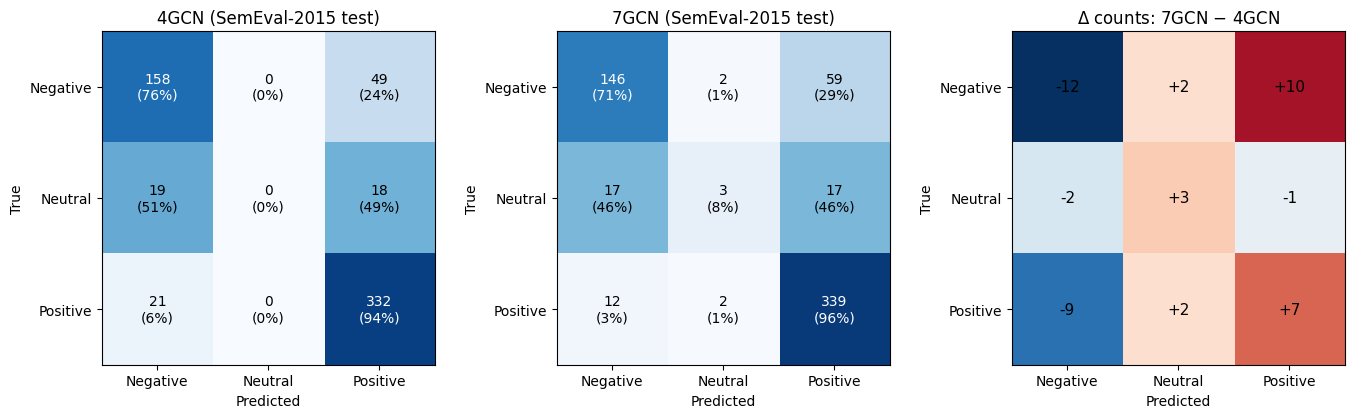


===== 4GCN =====
accuracy = 0.8908   macro F1 = 0.7030
class         prec     rec      F1  support
negative     0.750   0.822   0.784      135
neutral      0.800   0.250   0.381       32
positive     0.935   0.952   0.944      483
confusion matrix (rows = gold, cols = pred):
              nega    neut    posi
negative       111       1      23
neutral         15       8       9
positive        22       1     460

===== 7GCN =====
accuracy = 0.8985   macro F1 = 0.7329
class         prec     rec      F1  support
negative     0.836   0.756   0.794      135
neutral      0.688   0.344   0.458       32
positive     0.920   0.975   0.947      483
confusion matrix (rows = gold, cols = pred):
              nega    neut    posi
negative       102       2      31
neutral         11      11      10
positive         9       3     471

===== LaTeX table (SemEval-2016) =====
\begin{table}[htbp]
\centering
\caption{Per-class precision, recall, and F1 on the SemEval-2016 test set (4GCN vs. 7GCN, valid

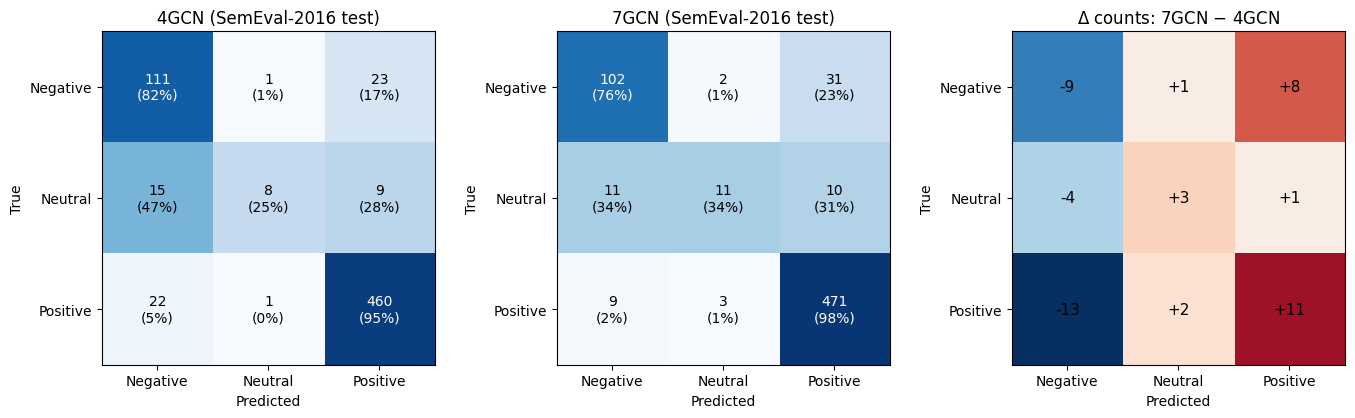

In [5]:
for year in YEARS:
    results = {}
    for model in MODELS:
        gold, pred = load_eval(EVAL[(model, year)])
        results[model] = confusion(gold, pred)

    for model in MODELS:
        print_report(model, results[model])

    print(f"\n===== LaTeX table (SemEval-{year}) =====")
    print(latex_table(results, year))

    names = list(results)
    fig, axes = plt.subplots(1, 3, figsize=(4.6 * 3, 4.2))
    for ax, name in zip(axes, names):
        draw_panel(ax, results[name], f"{name} (SemEval-{year} test)")
    draw_delta(axes[-1], results[names[0]], results[names[1]], *names)
    fig.tight_layout()

    out = OUT_DIR / f"confusion_{year}.pdf"
    fig.savefig(out, bbox_inches="tight", dpi=200)
    fig.savefig(out.with_suffix(".png"), bbox_inches="tight", dpi=200)
    print(f"\nsaved {out} and {out.with_suffix('.png')}")
    plt.show()